# Image Similarity Matching on CIFAR-10

This Colab notebook benchmarks image similarity / retrieval methods on **CIFAR-10**.

**Gallery / database:** all 50,000 CIFAR-10 training images  
**Queries:** all 10,000 CIFAR-10 test images  
**Relevance rule:** a retrieved image is relevant if it has the same CIFAR-10 class label as the query.

Methods included:

1. Color Histogram + HOG
2. SSIM-based retrieval
3. SIFT direct matching
4. BoVW with SIFT descriptors
5. EfficientNet-B0 transfer-learning embeddings
6. Siamese EfficientNet transfer-learning with contrastive loss
7. SigLIP image embeddings

Notes:

- CIFAR-10 images are only 32×32, so SIFT is not naturally strong here. The notebook upsamples images before SIFT detection.

## 0. Install dependencies

Run this first in Colab.

In [1]:
!pip -q install -U opencv-contrib-python-headless scikit-image scikit-learn transformers accelerate tqdm pandas matplotlib psutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 4.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas=

## 1. Imports and configuration

In [2]:
import os
import gc
import math
import time
import random
import warnings
import threading
from pathlib import Path
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from PIL import Image

import cv2
import psutil
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from skimage.feature import hog

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.datasets import CIFAR10
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Full CIFAR-10 benchmark: 50k train gallery, 10k test queries.
WORKDIR = Path("/content/image_similarity_cifar10")
WORKDIR.mkdir(parents=True, exist_ok=True)

# Retrieval metrics.
TOP_KS = (1, 5, 10)
F1_K = 10
EVAL_BATCH_SIZE = 128

# Stable Colab setting. Avoids Python 3.12 multiprocessing / semaphore issues.
NUM_WORKERS = 0

# Method switches. Defaults run the full benchmark.
RUN_COLOR_HOG = True
RUN_SSIM = True
RUN_BOVW = True
RUN_SIFT_DIRECT = True
RUN_EFFICIENTNET = True
RUN_SIAMESE = True
RUN_SIGLIP = True

# Classical feature settings.
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
COLOR_HIST_BINS = 8

# SSIM settings.
# Uses full-database MSE prefilter, then global SSIM formula re-ranks top candidates.
SSIM_SHORTLIST = 200
SSIM_SIZE = (32, 32)

# SIFT / BoVW settings.
# CIFAR-10 is tiny, so images are upsampled before SIFT.
SIFT_IMAGE_SIZE = (128, 128)
SIFT_NFEATURES = 64
SIFT_RATIO_TEST = 0.75
BOVW_CLUSTERS = 128
BOVW_MAX_DESC_FOR_VOCAB = 200_000
SIFT_DIRECT_SHORTLIST = 100

# EfficientNet settings.
DEEP_BATCH_SIZE = 256 if DEVICE == "cuda" else 64

# Siamese transfer-learning settings.
SIAMESE_EPOCHS = 2
SIAMESE_PAIRS_PER_EPOCH = 50_000     # one full train-size epoch of random positive/negative pairs
SIAMESE_BATCH_SIZE = 128 if DEVICE == "cuda" else 64
SIAMESE_LR = 1e-3
SIAMESE_MARGIN = 1.0
SIAMESE_FREEZE_BACKBONE = True       # practical default; set False to fine-tune backbone too
SIAMESE_EMBED_DIM = 128

# SigLIP settings.
SIGLIP_MODEL_ID = "google/siglip-base-patch16-224"
SIGLIP_BATCH_SIZE = 128 if DEVICE == "cuda" else 32

print("Workdir:", WORKDIR)

Device: cpu
Workdir: /content/image_similarity_cifar10


## 2. Download and load CIFAR-10 online

The notebook downloads CIFAR-10 automatically through `torchvision.datasets.CIFAR10`, so no manual upload is needed.

In [3]:
DATA_ROOT = WORKDIR / "data"

train_set = CIFAR10(root=str(DATA_ROOT), train=True, download=True)
test_set = CIFAR10(root=str(DATA_ROOT), train=False, download=True)

class_names = train_set.classes
print("Classes:", class_names)
print("Train/gallery size:", len(train_set))
print("Test/query size:", len(test_set))

# Materialize as numpy arrays for classical CV methods.
db_images = np.stack([np.array(img.convert("RGB"), dtype=np.uint8) for img, _ in tqdm(train_set, desc="Materialize train/gallery")])
db_labels = np.array([label for _, label in train_set], dtype=np.int64)

q_images = np.stack([np.array(img.convert("RGB"), dtype=np.uint8) for img, _ in tqdm(test_set, desc="Materialize test/query")])
q_labels = np.array([label for _, label in test_set], dtype=np.int64)

num_classes = len(class_names)
relevant_count_by_label = np.bincount(db_labels, minlength=num_classes).astype(np.int64)

print("db_images:", db_images.shape, db_images.dtype)
print("q_images:", q_images.shape, q_images.dtype)
print("Relevant gallery images per class:", dict(zip(class_names, relevant_count_by_label.tolist())))

100%|██████████| 170M/170M [29:22<00:00, 96.8kB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train/gallery size: 50000
Test/query size: 10000


Materialize train/gallery:   0%|          | 0/50000 [00:00<?, ?it/s]

Materialize test/query:   0%|          | 0/10000 [00:00<?, ?it/s]

db_images: (50000, 32, 32, 3) uint8
q_images: (10000, 32, 32, 3) uint8
Relevant gallery images per class: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


## 3. Quick dataset visualization

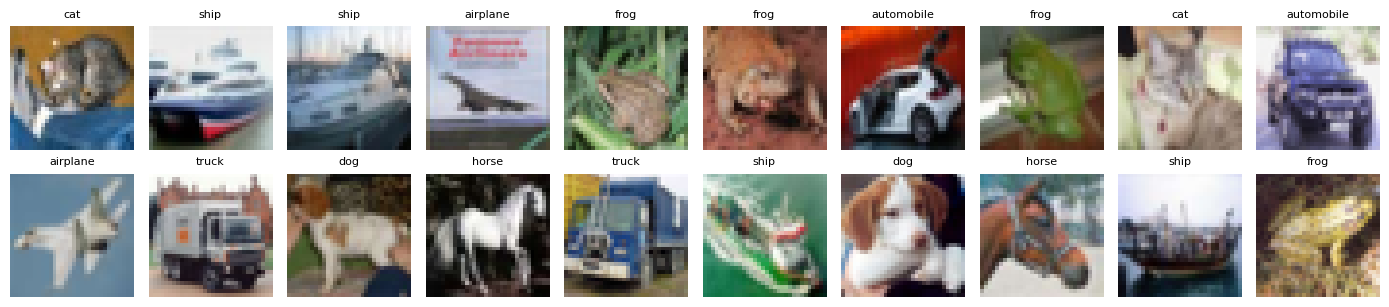

In [4]:
def show_cifar_examples(images, labels, n=20):
    cols = 10
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 1.4, rows * 1.6))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_cifar_examples(q_images, q_labels, n=20)

## 4. Evaluation utilities

For CIFAR-10 retrieval, a database image is relevant if its class label equals the query class label.

In [5]:
def l2_normalize_np(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.nan_to_num(np.asarray(x, dtype=np.float32))
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norms, eps)

class MetricAccumulator:
    def __init__(self, db_labels: np.ndarray, q_labels: np.ndarray, relevant_count_by_label: np.ndarray,
                 top_ks=TOP_KS, f1_k=F1_K):
        self.db_labels = db_labels
        self.q_labels = q_labels
        self.relevant_count_by_label = relevant_count_by_label
        self.top_ks = tuple(top_ks)
        self.f1_k = int(f1_k)
        self.aps = []
        self.top1 = []
        self.pks = {k: [] for k in self.top_ks}
        self.rks = {k: [] for k in self.top_ks}
        self.f1s = []

    def update_order(self, order: np.ndarray, query_label: int):
        ranked_labels = self.db_labels[order]
        rel = (ranked_labels == int(query_label))
        n_rel = int(self.relevant_count_by_label[int(query_label)])
        if n_rel <= 0:
            return

        # Average Precision over the full ranking.
        cumsum = np.cumsum(rel, dtype=np.float32)
        ranks = np.arange(1, len(rel) + 1, dtype=np.float32)
        if rel.any():
            ap = float(np.sum((cumsum / ranks) * rel) / n_rel)
        else:
            ap = 0.0
        self.aps.append(ap)
        self.top1.append(float(rel[0]))

        for k in self.top_ks:
            rel_top = rel[:k]
            p = float(np.sum(rel_top) / k)
            r = float(np.sum(rel_top) / n_rel)
            self.pks[k].append(p)
            self.rks[k].append(r)

        rel_top = rel[:self.f1_k]
        p = float(np.sum(rel_top) / self.f1_k)
        r = float(np.sum(rel_top) / n_rel)
        f1 = 0.0 if (p + r) == 0 else float(2 * p * r / (p + r))
        self.f1s.append(f1)

    def result(self, method: str) -> Dict[str, float]:
        out = {
            "method": method,
            "mAP": float(np.mean(self.aps)),
            "Top1": float(np.mean(self.top1)),
        }
        for k in self.top_ks:
            out[f"P@{k}"] = float(np.mean(self.pks[k]))
        for k in self.top_ks:
            out[f"R@{k}"] = float(np.mean(self.rks[k]))
        out[f"F1@{self.f1_k}"] = float(np.mean(self.f1s))
        return out

class ResourceTracker:
    """Wall-time + approximate CPU/GPU peak memory tracker."""
    def __init__(self, sample_interval: float = 0.25):
        self.sample_interval = sample_interval
        self.process = psutil.Process(os.getpid())
        self._stop = threading.Event()
        self._thread = None
        self.peak_rss_bytes = 0
        self.peak_gpu_allocated_bytes = 0
        self.peak_gpu_reserved_bytes = 0
        self.seconds = 0.0

    def _sample_once(self):
        try:
            self.peak_rss_bytes = max(self.peak_rss_bytes, self.process.memory_info().rss)
        except Exception:
            pass
        if torch.cuda.is_available():
            try:
                self.peak_gpu_allocated_bytes = max(self.peak_gpu_allocated_bytes, torch.cuda.max_memory_allocated())
                self.peak_gpu_reserved_bytes = max(self.peak_gpu_reserved_bytes, torch.cuda.max_memory_reserved())
            except Exception:
                pass

    def _worker(self):
        while not self._stop.is_set():
            self._sample_once()
            time.sleep(self.sample_interval)

    def __enter__(self):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        self.t0 = time.time()
        self._sample_once()
        self._thread = threading.Thread(target=self._worker, daemon=True)
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc, tb):
        self._stop.set()
        if self._thread is not None:
            self._thread.join(timeout=1.0)
        self._sample_once()
        self.seconds = time.time() - self.t0

def add_runtime_metrics(result: Dict[str, float], tracker: ResourceTracker, n_queries: int) -> Dict[str, float]:
    result = dict(result)
    result["seconds"] = float(tracker.seconds)
    result["latency_ms_per_query"] = float(1000.0 * tracker.seconds / max(1, n_queries))
    result["peak_ram_mb"] = float(tracker.peak_rss_bytes / (1024 ** 2))
    result["peak_gpu_allocated_mb"] = float(tracker.peak_gpu_allocated_bytes / (1024 ** 2))
    result["peak_gpu_reserved_mb"] = float(tracker.peak_gpu_reserved_bytes / (1024 ** 2))
    result["memory_usage_mb"] = result["peak_ram_mb"] + result["peak_gpu_reserved_mb"]
    return result

def evaluate_feature_retrieval(method: str, q_feats: np.ndarray, db_feats: np.ndarray,
                               db_labels: np.ndarray, q_labels: np.ndarray,
                               metric: str = "cosine", batch_size: int = EVAL_BATCH_SIZE) -> Dict[str, float]:
    """Evaluate full query-gallery retrieval from feature vectors using batched full ranking."""
    assert metric in {"cosine", "euclidean"}
    q_feats = np.nan_to_num(q_feats.astype(np.float32))
    db_feats = np.nan_to_num(db_feats.astype(np.float32))
    if metric == "cosine":
        q_feats = l2_normalize_np(q_feats)
        db_feats = l2_normalize_np(db_feats)
    acc = MetricAccumulator(db_labels, q_labels, relevant_count_by_label)
    db_t = torch.from_numpy(db_feats).to(DEVICE)
    if metric == "euclidean":
        db_sq = (db_t ** 2).sum(dim=1).view(1, -1)

    for start in tqdm(range(0, len(q_feats), batch_size), desc=f"Evaluate {method}"):
        q_batch = torch.from_numpy(q_feats[start:start + batch_size]).to(DEVICE)
        with torch.inference_mode():
            if metric == "cosine":
                scores = q_batch @ db_t.T
            else:
                q_sq = (q_batch ** 2).sum(dim=1, keepdim=True)
                scores = -(q_sq + db_sq - 2.0 * (q_batch @ db_t.T))
            order = torch.argsort(scores, dim=1, descending=True).cpu().numpy()
        for j in range(order.shape[0]):
            acc.update_order(order[j], int(q_labels[start + j]))
        del q_batch, scores, order
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    del db_t
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return acc.result(method)

results = []

## 5. Classical feature helpers

In [6]:
def rgb_to_gray_float(images: np.ndarray, size: Tuple[int, int] = (32, 32)) -> np.ndarray:
    out = []
    for img in tqdm(images, desc="RGB -> gray"):
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        if size is not None:
            gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
        out.append(gray.astype(np.float32) / 255.0)
    return np.stack(out, axis=0)

def extract_color_hog_features(images: np.ndarray) -> np.ndarray:
    feats = []
    for img in tqdm(images, desc="Color Histogram + HOG"):
        # Color histogram: separate normalized histograms for RGB channels.
        hist_parts = []
        for ch in range(3):
            hist = cv2.calcHist([img], [ch], None, [COLOR_HIST_BINS], [0, 256]).flatten()
            hist = hist / (hist.sum() + 1e-12)
            hist_parts.append(hist)

        # HOG on grayscale 32x32 image.
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        hog_vec = hog(
            gray,
            orientations=9,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            block_norm="L2-Hys",
            feature_vector=True,
        ).astype(np.float32)

        feat = np.concatenate(hist_parts + [hog_vec.astype(np.float32)], axis=0)
        feats.append(feat)

    return l2_normalize_np(np.stack(feats, axis=0))

def resize_for_sift(img: np.ndarray, size=SIFT_IMAGE_SIZE) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, size, interpolation=cv2.INTER_CUBIC)
    return gray

def make_sift():
    return cv2.SIFT_create(nfeatures=SIFT_NFEATURES)

## 6. Method 1 — Color Histogram + HOG

In [7]:
if RUN_COLOR_HOG:
    with ResourceTracker() as tracker:
        db_color_hog = extract_color_hog_features(db_images)
        q_color_hog = extract_color_hog_features(q_images)
        result = evaluate_feature_retrieval("Color Histogram + HOG", q_color_hog, db_color_hog, db_labels, q_labels)

    result = add_runtime_metrics(result, tracker, n_queries=len(q_images))
    results.append(result)
    print(result)

    del db_color_hog, q_color_hog
    gc.collect()

Color Histogram + HOG:   0%|          | 0/50000 [00:00<?, ?it/s]

Color Histogram + HOG:   0%|          | 0/10000 [00:00<?, ?it/s]

Evaluate Color Histogram + HOG:   0%|          | 0/79 [00:00<?, ?it/s]

{'method': 'Color Histogram + HOG', 'mAP': 0.15733621882498264, 'Top1': 0.4837, 'P@1': 0.4837, 'P@5': 0.42153999999999997, 'P@10': 0.39577999999999997, 'R@1': 9.674000000000001e-05, 'R@5': 0.00042154, 'R@10': 0.0007915600000000001, 'F1@10': 0.0015799600798403195, 'seconds': 104.99865007400513, 'latency_ms_per_query': 10.499865007400512, 'peak_ram_mb': 1276.1875, 'peak_gpu_allocated_mb': 0.0, 'peak_gpu_reserved_mb': 0.0, 'memory_usage_mb': 1276.1875}


## 7. Method 2 — SSIM-based retrieval

Exact SSIM against all 50,000 gallery images for all 10,000 queries is very slow. This cell does:

1. Full-database MSE-style prefilter using all gallery images.
2. Global SSIM re-ranking of the top `SSIM_SHORTLIST` candidates.
3. Full ranking = SSIM re-ranked shortlist + remaining gallery images in prefilter order.

This evaluates every query against the full gallery while keeping runtime manageable.

In [8]:
def global_ssim_scores(query_gray: np.ndarray, cand_gray: np.ndarray) -> np.ndarray:
    """Fast vectorized global SSIM formula for one query and many candidates."""
    q = query_gray.astype(np.float32)
    c = cand_gray.astype(np.float32)
    C1 = (0.01 ** 2)
    C2 = (0.03 ** 2)

    mux = float(q.mean())
    muy = c.mean(axis=(1, 2))
    q_centered = q - mux
    c_centered = c - muy[:, None, None]

    var_x = float((q_centered ** 2).mean())
    var_y = (c_centered ** 2).mean(axis=(1, 2))
    cov_xy = (c_centered * q_centered[None, :, :]).mean(axis=(1, 2))

    num = (2 * mux * muy + C1) * (2 * cov_xy + C2)
    den = (mux ** 2 + muy ** 2 + C1) * (var_x + var_y + C2)
    return (num / np.maximum(den, 1e-12)).astype(np.float32)

def evaluate_ssim_retrieval(db_images: np.ndarray, q_images: np.ndarray) -> Dict[str, float]:
    db_gray = rgb_to_gray_float(db_images, size=SSIM_SIZE)
    q_gray = rgb_to_gray_float(q_images, size=SSIM_SIZE)
    db_flat = db_gray.reshape(len(db_gray), -1).astype(np.float32)
    q_flat = q_gray.reshape(len(q_gray), -1).astype(np.float32)
    db_t = torch.from_numpy(db_flat).to(DEVICE)
    db_sq = (db_t ** 2).sum(dim=1).view(1, -1)
    acc = MetricAccumulator(db_labels, q_labels, relevant_count_by_label)

    for start in tqdm(range(0, len(q_flat), EVAL_BATCH_SIZE), desc="SSIM retrieval"):
        q_batch_np = q_flat[start:start + EVAL_BATCH_SIZE]
        q_batch = torch.from_numpy(q_batch_np).to(DEVICE)
        with torch.inference_mode():
            q_sq = (q_batch ** 2).sum(dim=1, keepdim=True)
            mse_scores = -(q_sq + db_sq - 2.0 * (q_batch @ db_t.T))
            prefilter_orders = torch.argsort(mse_scores, dim=1, descending=True).cpu().numpy()

        for j in range(prefilter_orders.shape[0]):
            qi = start + j
            order = prefilter_orders[j]
            shortlist = order[:SSIM_SHORTLIST]
            ssim_scores = global_ssim_scores(q_gray[qi], db_gray[shortlist])
            reranked_shortlist = shortlist[np.argsort(-ssim_scores)]
            full_order = np.concatenate([reranked_shortlist, order[SSIM_SHORTLIST:]])
            acc.update_order(full_order, int(q_labels[qi]))

        del q_batch, mse_scores, prefilter_orders
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    del db_t, db_gray, q_gray, db_flat, q_flat
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return acc.result(f"SSIM rerank top-{SSIM_SHORTLIST} after full MSE prefilter")

if RUN_SSIM:
    with ResourceTracker() as tracker:
        result = evaluate_ssim_retrieval(db_images, q_images)
    result = add_runtime_metrics(result, tracker, n_queries=len(q_images))
    results.append(result)
    print(result)
    gc.collect()

RGB -> gray:   0%|          | 0/50000 [00:00<?, ?it/s]

RGB -> gray:   0%|          | 0/10000 [00:00<?, ?it/s]

SSIM retrieval:   0%|          | 0/79 [00:00<?, ?it/s]

{'method': 'SSIM rerank top-200 after full MSE prefilter', 'mAP': 0.1274293980062008, 'Top1': 0.3675, 'P@1': 0.3675, 'P@5': 0.30822000000000005, 'P@10': 0.28202999999999995, 'R@1': 7.350000000000001e-05, 'R@5': 0.00030822000000000005, 'R@10': 0.0005640599999999999, 'F1@10': 0.001125868263473054, 'seconds': 100.49273347854614, 'latency_ms_per_query': 10.049273347854614, 'peak_ram_mb': 1744.125, 'peak_gpu_allocated_mb': 0.0, 'peak_gpu_reserved_mb': 0.0, 'memory_usage_mb': 1744.125}


## 8. SIFT and BoVW helpers

In [9]:
def extract_sift_descriptors(images: np.ndarray) -> List[Optional[np.ndarray]]:
    sift = make_sift()
    descs = []
    for img in tqdm(images, desc="Extract SIFT descriptors"):
        gray = resize_for_sift(img)
        _, d = sift.detectAndCompute(gray, None)
        if d is None or len(d) == 0:
            descs.append(None)
        else:
            descs.append(d.astype(np.float32))
    return descs

def fit_bovw_vocab(db_descs: List[Optional[np.ndarray]]) -> MiniBatchKMeans:
    rng = np.random.default_rng(SEED)
    collected = []
    total = 0

    indices = np.arange(len(db_descs))
    rng.shuffle(indices)

    for idx in tqdm(indices, desc="Collect descriptors for BoVW vocab"):
        d = db_descs[int(idx)]
        if d is None or len(d) == 0:
            continue
        if len(d) > SIFT_NFEATURES:
            chosen = rng.choice(len(d), size=SIFT_NFEATURES, replace=False)
            d = d[chosen]
        collected.append(d)
        total += len(d)
        if total >= BOVW_MAX_DESC_FOR_VOCAB:
            break

    if not collected:
        raise RuntimeError("No SIFT descriptors found. Try increasing SIFT_NFEATURES or SIFT_IMAGE_SIZE.")

    all_desc = np.vstack(collected).astype(np.float32)
    print("Descriptor sample for vocabulary:", all_desc.shape)

    kmeans = MiniBatchKMeans(
        n_clusters=BOVW_CLUSTERS,
        batch_size=4096,
        random_state=SEED,
        n_init="auto",
        verbose=0,
    )
    kmeans.fit(all_desc)
    return kmeans

def encode_bovw(descs: List[Optional[np.ndarray]], kmeans: MiniBatchKMeans) -> np.ndarray:
    feats = []
    for d in tqdm(descs, desc="Encode BoVW histograms"):
        hist = np.zeros(BOVW_CLUSTERS, dtype=np.float32)
        if d is not None and len(d) > 0:
            words = kmeans.predict(d.astype(np.float32))
            hist += np.bincount(words, minlength=BOVW_CLUSTERS).astype(np.float32)
        hist = hist / (hist.sum() + 1e-12)
        feats.append(hist)
    return l2_normalize_np(np.stack(feats, axis=0))

def sift_match_score(desc1: Optional[np.ndarray],
                     desc2: Optional[np.ndarray],
                     ratio: float = SIFT_RATIO_TEST) -> float:
    """
    Direct SIFT image-pair score using Lowe's ratio test.

    For every descriptor in desc1, BFMatcher finds the two nearest descriptors in desc2.
    A match is counted only if d(best) < ratio * d(second_best).

    The returned score is normalized by the smaller descriptor count so that images with
    many keypoints do not win only because they contain more descriptors.

    This score is the one used for final SIFT re-ranking, so P@K/R@K/F1@K are computed
    from rankings after Lowe's ratio filtering.
    """
    if desc1 is None or desc2 is None or len(desc1) < 2 or len(desc2) < 2:
        return 0.0

    desc1 = desc1.astype(np.float32, copy=False)
    desc2 = desc2.astype(np.float32, copy=False)

    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    try:
        knn_matches = bf.knnMatch(desc1, desc2, k=2)
    except cv2.error:
        return 0.0

    good = 0
    for pair in knn_matches:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good += 1

    return float(good / max(1, min(len(desc1), len(desc2))))

## 9. Method 3 — BoVW with SIFT descriptors

In [10]:
db_sift_descs = None
q_sift_descs = None
db_bovw = None
q_bovw = None

if RUN_BOVW or RUN_SIFT_DIRECT:
    with ResourceTracker() as tracker_sift_extract:
        db_sift_descs = extract_sift_descriptors(db_images)
        q_sift_descs = extract_sift_descriptors(q_images)
    print("SIFT descriptor extraction seconds:", tracker_sift_extract.seconds)

if RUN_BOVW:
    with ResourceTracker() as tracker:
        kmeans = fit_bovw_vocab(db_sift_descs)
        db_bovw = encode_bovw(db_sift_descs, kmeans)
        q_bovw = encode_bovw(q_sift_descs, kmeans)
        result = evaluate_feature_retrieval("BoVW SIFT", q_bovw, db_bovw, db_labels, q_labels)
    # Add SIFT extraction time into BoVW runtime to reflect full pipeline cost.
    tracker.seconds += tracker_sift_extract.seconds
    tracker.peak_rss_bytes = max(tracker.peak_rss_bytes, tracker_sift_extract.peak_rss_bytes)
    tracker.peak_gpu_allocated_bytes = max(tracker.peak_gpu_allocated_bytes, tracker_sift_extract.peak_gpu_allocated_bytes)
    tracker.peak_gpu_reserved_bytes = max(tracker.peak_gpu_reserved_bytes, tracker_sift_extract.peak_gpu_reserved_bytes)
    result = add_runtime_metrics(result, tracker, n_queries=len(q_images))
    results.append(result)
    print(result)

Extract SIFT descriptors:   0%|          | 0/50000 [00:00<?, ?it/s]

Extract SIFT descriptors:   0%|          | 0/10000 [00:00<?, ?it/s]

SIFT descriptor extraction seconds: 378.4875257015228


Collect descriptors for BoVW vocab:   0%|          | 0/50000 [00:00<?, ?it/s]

Descriptor sample for vocabulary: (200027, 128)


Encode BoVW histograms:   0%|          | 0/50000 [00:00<?, ?it/s]

Encode BoVW histograms:   0%|          | 0/10000 [00:00<?, ?it/s]

Evaluate BoVW SIFT:   0%|          | 0/79 [00:00<?, ?it/s]

{'method': 'BoVW SIFT', 'mAP': 0.12005073619261385, 'Top1': 0.222, 'P@1': 0.222, 'P@5': 0.19726, 'P@10': 0.18968, 'R@1': 4.440000000000001e-05, 'R@5': 0.00019726000000000002, 'R@10': 0.00037935999999999997, 'F1@10': 0.0007572055888223554, 'seconds': 470.2153582572937, 'latency_ms_per_query': 47.02153582572937, 'peak_ram_mb': 2489.8671875, 'peak_gpu_allocated_mb': 0.0, 'peak_gpu_reserved_mb': 0.0, 'memory_usage_mb': 2489.8671875}


## 10. Method 4 — SIFT direct matching

Exact direct SIFT matching from every query to every gallery image is too expensive. This cell uses:

1. BoVW cosine ranking over the full gallery.
2. Direct SIFT + Lowe ratio test re-ranking of the top `SIFT_DIRECT_SHORTLIST` candidates.
3. Full ranking = direct-SIFT re-ranked shortlist + remaining gallery images in BoVW order.

In [11]:
def evaluate_sift_direct_rerank(q_descs, db_descs, q_bovw, db_bovw) -> Dict[str, float]:
    q_bovw_n = l2_normalize_np(q_bovw)
    db_bovw_n = l2_normalize_np(db_bovw)
    db_t = torch.from_numpy(db_bovw_n.astype(np.float32)).to(DEVICE)
    acc = MetricAccumulator(db_labels, q_labels, relevant_count_by_label)

    for start in tqdm(range(0, len(q_bovw_n), EVAL_BATCH_SIZE), desc="SIFT direct rerank"):
        q_batch = torch.from_numpy(q_bovw_n[start:start + EVAL_BATCH_SIZE].astype(np.float32)).to(DEVICE)
        with torch.inference_mode():
            scores = q_batch @ db_t.T
            prefilter_orders = torch.argsort(scores, dim=1, descending=True).cpu().numpy()

        for j in range(prefilter_orders.shape[0]):
            qi = start + j
            order = prefilter_orders[j]
            shortlist = order[:SIFT_DIRECT_SHORTLIST]
            match_scores = np.array([sift_match_score(q_descs[qi], db_descs[int(di)]) for di in shortlist], dtype=np.float32)
            reranked_shortlist = shortlist[np.argsort(-match_scores)]
            full_order = np.concatenate([reranked_shortlist, order[SIFT_DIRECT_SHORTLIST:]])
            acc.update_order(full_order, int(q_labels[qi]))

        del q_batch, scores, prefilter_orders
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    del db_t
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return acc.result(f"SIFT direct rerank top-{SIFT_DIRECT_SHORTLIST} after full BoVW prefilter")

if RUN_SIFT_DIRECT:
    if db_bovw is None or q_bovw is None:
        print("BoVW was not run. Building BoVW features now for SIFT direct prefilter.")
        kmeans = fit_bovw_vocab(db_sift_descs)
        db_bovw = encode_bovw(db_sift_descs, kmeans)
        q_bovw = encode_bovw(q_sift_descs, kmeans)
    with ResourceTracker() as tracker:
        result = evaluate_sift_direct_rerank(q_sift_descs, db_sift_descs, q_bovw, db_bovw)
    # Add SIFT extraction time into direct-SIFT runtime to reflect full pipeline cost.
    tracker.seconds += tracker_sift_extract.seconds
    tracker.peak_rss_bytes = max(tracker.peak_rss_bytes, tracker_sift_extract.peak_rss_bytes)
    tracker.peak_gpu_allocated_bytes = max(tracker.peak_gpu_allocated_bytes, tracker_sift_extract.peak_gpu_allocated_bytes)
    tracker.peak_gpu_reserved_bytes = max(tracker.peak_gpu_reserved_bytes, tracker_sift_extract.peak_gpu_reserved_bytes)
    result = add_runtime_metrics(result, tracker, n_queries=len(q_images))
    results.append(result)
    print(result)

SIFT direct rerank:   0%|          | 0/79 [00:00<?, ?it/s]

{'method': 'SIFT direct rerank top-100 after full BoVW prefilter', 'mAP': 0.12008264638781548, 'Top1': 0.2362, 'P@1': 0.2362, 'P@5': 0.2069, 'P@10': 0.1975, 'R@1': 4.724e-05, 'R@5': 0.0002069, 'R@10': 0.000395, 'F1@10': 0.0007884231536926149, 'seconds': 569.6232523918152, 'latency_ms_per_query': 56.96232523918152, 'peak_ram_mb': 2623.6171875, 'peak_gpu_allocated_mb': 0.0, 'peak_gpu_reserved_mb': 0.0, 'memory_usage_mb': 2623.6171875}


## 11. Deep embedding helpers

In [12]:
class NumpyImageDataset(Dataset):
    def __init__(self, images: np.ndarray, transform=None):
        self.images = images
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img

def tensor_from_model_output(x):
    """Robustly extract a tensor from common model output containers."""
    if torch.is_tensor(x):
        return x
    for attr in ["image_embeds", "pooler_output", "last_hidden_state", "logits"]:
        if hasattr(x, attr):
            v = getattr(x, attr)
            if torch.is_tensor(v):
                if attr == "last_hidden_state" and v.ndim == 3:
                    return v[:, 0]
                return v
    if isinstance(x, (tuple, list)) and len(x) > 0:
        return tensor_from_model_output(x[0])
    raise TypeError(f"Cannot extract tensor from output type: {type(x)}")

def extract_embeddings_torch(model, images: np.ndarray, transform, batch_size: int = DEEP_BATCH_SIZE,
                             desc: str = "embeddings") -> np.ndarray:
    ds = NumpyImageDataset(images, transform=transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS,
                    pin_memory=(DEVICE == "cuda"), persistent_workers=False)

    if hasattr(model, "eval"):
        model.eval()
    feats = []
    for x in tqdm(dl, desc=desc):
        x = x.to(DEVICE, non_blocking=True)
        with torch.inference_mode():
            z = model(x)
            z = tensor_from_model_output(z)
            if z.ndim > 2:
                z = torch.flatten(z, start_dim=1)
            z = F.normalize(z.float(), dim=1)
        feats.append(z.detach().cpu().numpy())
    return np.vstack(feats).astype(np.float32)

## 12. Method 5 — EfficientNet-B0 transfer-learning embeddings

This uses ImageNet-pretrained EfficientNet-B0 as a fixed feature extractor.

In [13]:
if RUN_EFFICIENTNET:
    with ResourceTracker() as tracker:
        weights = EfficientNet_B0_Weights.DEFAULT
        effnet = efficientnet_b0(weights=weights)
        effnet.classifier = nn.Identity()
        effnet = effnet.to(DEVICE)
        effnet_transform = weights.transforms()

        db_effnet = extract_embeddings_torch(effnet, db_images, effnet_transform, batch_size=DEEP_BATCH_SIZE, desc="EfficientNet db")
        q_effnet = extract_embeddings_torch(effnet, q_images, effnet_transform, batch_size=DEEP_BATCH_SIZE, desc="EfficientNet queries")
        result = evaluate_feature_retrieval("EfficientNet-B0 ImageNet transfer", q_effnet, db_effnet, db_labels, q_labels)

    result = add_runtime_metrics(result, tracker, n_queries=len(q_images))
    results.append(result)
    print(result)

    del effnet, db_effnet, q_effnet
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 119MB/s] 


EfficientNet db:   0%|          | 0/782 [00:00<?, ?it/s]

EfficientNet queries:   0%|          | 0/157 [00:00<?, ?it/s]

Evaluate EfficientNet-B0 ImageNet transfer:   0%|          | 0/79 [00:00<?, ?it/s]

{'method': 'EfficientNet-B0 ImageNet transfer', 'mAP': 0.4740835779428482, 'Top1': 0.884, 'P@1': 0.884, 'P@5': 0.8584799999999999, 'P@10': 0.8449, 'R@1': 0.00017680000000000004, 'R@5': 0.0008584800000000001, 'R@10': 0.0016898000000000004, 'F1@10': 0.0033728542914171654, 'seconds': 5768.961413860321, 'latency_ms_per_query': 576.8961413860321, 'peak_ram_mb': 4051.44140625, 'peak_gpu_allocated_mb': 0.0, 'peak_gpu_reserved_mb': 0.0, 'memory_usage_mb': 4051.44140625}


## 13. Method 6 — Siamese EfficientNet transfer learning with contrastive loss

- shared ImageNet-pretrained EfficientNet-B0 backbone;
- projection head trained using contrastive loss;
- positive pairs = same CIFAR-10 class;
- negative pairs = different CIFAR-10 classes.

`DataLoader(num_workers=0)` is used to avoid Colab/Python 3.12 multiprocessing semaphore errors.

In [ ]:
class CIFARSiamesePairDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray, transform, pairs_per_epoch: int):
        self.images = images
        self.labels = labels
        self.transform = transform
        self.pairs_per_epoch = int(pairs_per_epoch)
        self.by_label = {c: np.flatnonzero(labels == c) for c in np.unique(labels)}
        self.classes = sorted(self.by_label.keys())

    def __len__(self):
        return self.pairs_per_epoch

    def __getitem__(self, idx):
        # Use numpy random for simple stochastic pair generation.
        c1 = int(np.random.choice(self.classes))
        idx1 = int(np.random.choice(self.by_label[c1]))
        is_positive = bool(np.random.rand() < 0.5)

        if is_positive:
            idx2 = int(np.random.choice(self.by_label[c1]))
            y = 1.0
        else:
            other_classes = [c for c in self.classes if c != c1]
            c2 = int(np.random.choice(other_classes))
            idx2 = int(np.random.choice(self.by_label[c2]))
            y = 0.0

        img1 = Image.fromarray(self.images[idx1]).convert("RGB")
        img2 = Image.fromarray(self.images[idx2]).convert("RGB")
        return self.transform(img1), self.transform(img2), torch.tensor(y, dtype=torch.float32)

class SiameseEfficientNet(nn.Module):
    def __init__(self, embedding_dim: int = SIAMESE_EMBED_DIM, freeze_backbone: bool = SIAMESE_FREEZE_BACKBONE):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT
        self.backbone = efficientnet_b0(weights=weights)
        self.backbone.classifier = nn.Identity()
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(512, embedding_dim),
        )

    def forward_once(self, x):
        z = self.backbone(x)
        z = tensor_from_model_output(z)
        z = self.projection(z)
        return F.normalize(z, dim=1)

    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)

def contrastive_loss(z1, z2, y, margin=SIAMESE_MARGIN):
    # y = 1 similar, y = 0 dissimilar.
    d = F.pairwise_distance(z1, z2)
    loss_pos = y * d.pow(2)
    loss_neg = (1.0 - y) * F.relu(margin - d).pow(2)
    return torch.mean(loss_pos + loss_neg)

def train_siamese_model() -> Tuple[SiameseEfficientNet, object]:
    weights = EfficientNet_B0_Weights.DEFAULT
    transform = weights.transforms()

    model = SiameseEfficientNet().to(DEVICE)
    ds = CIFARSiamesePairDataset(db_images, db_labels, transform=transform, pairs_per_epoch=SIAMESE_PAIRS_PER_EPOCH)
    dl = DataLoader(ds, batch_size=SIAMESE_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                    pin_memory=(DEVICE == "cuda"), persistent_workers=False, drop_last=False)

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=SIAMESE_LR, weight_decay=1e-4)

    model.train()
    for epoch in range(1, SIAMESE_EPOCHS + 1):
        losses = []
        for x1, x2, y in tqdm(dl, desc=f"Siamese train epoch {epoch}/{SIAMESE_EPOCHS}"):
            x1 = x1.to(DEVICE, non_blocking=True)
            x2 = x2.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            z1, z2 = model(x1, x2)
            loss = contrastive_loss(z1, z2, y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            losses.append(float(loss.detach().cpu()))
        print(f"Epoch {epoch}: loss={np.mean(losses):.4f}")
    return model, transform

if RUN_SIAMESE:
    with ResourceTracker() as tracker:
        siamese_model, siamese_transform = train_siamese_model()
        # Extract using the trained Siamese branch.
        db_siamese = extract_embeddings_torch(siamese_model.forward_once, db_images, siamese_transform,
                                              batch_size=DEEP_BATCH_SIZE, desc="Siamese db")
        q_siamese = extract_embeddings_torch(siamese_model.forward_once, q_images, siamese_transform,
                                             batch_size=DEEP_BATCH_SIZE, desc="Siamese queries")
        result = evaluate_feature_retrieval("Siamese EfficientNet contrastive transfer", q_siamese, db_siamese, db_labels, q_labels)

    result = add_runtime_metrics(result, tracker, n_queries=len(q_images))
    results.append(result)
    print(result)

    del siamese_model, db_siamese, q_siamese
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

Siamese train epoch 1/2:   0%|          | 0/782 [00:00<?, ?it/s]

## 14. Method 7 — SigLIP image embeddings

This cell extracts image-only SigLIP embeddings.

In [ ]:
from transformers import AutoModel, AutoProcessor

def extract_siglip_embeddings(images: np.ndarray, model_id: str = SIGLIP_MODEL_ID, batch_size: int = SIGLIP_BATCH_SIZE) -> np.ndarray:
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(DEVICE)
    model.eval()

    feats = []
    for start in tqdm(range(0, len(images), batch_size), desc="SigLIP embeddings"):
        batch_np = images[start:start + batch_size]
        batch_pil = [Image.fromarray(img).convert("RGB") for img in batch_np]
        inputs = processor(images=batch_pil, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(DEVICE)

        with torch.inference_mode():
            z = None
            if hasattr(model, "get_image_features"):
                z = model.get_image_features(pixel_values=pixel_values)
            if z is None:
                outputs = model.vision_model(pixel_values=pixel_values)
                z = tensor_from_model_output(outputs)
                if hasattr(model, "visual_projection"):
                    try:
                        z = model.visual_projection(z)
                    except Exception:
                        pass
            z = tensor_from_model_output(z)
            if z.ndim > 2:
                z = torch.flatten(z, start_dim=1)
            z = F.normalize(z.float(), dim=1)

        feats.append(z.detach().cpu().numpy())
        del pixel_values, inputs, z
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()
    return np.vstack(feats).astype(np.float32)


if RUN_SIGLIP:
    with ResourceTracker() as tracker:
        db_siglip = extract_siglip_embeddings(db_images, batch_size=SIGLIP_BATCH_SIZE)
        q_siglip = extract_siglip_embeddings(q_images, batch_size=SIGLIP_BATCH_SIZE)
        result = evaluate_feature_retrieval("SigLIP image embeddings", q_siglip, db_siglip, db_labels, q_labels)

    result = add_runtime_metrics(result, tracker, n_queries=len(q_images))
    results.append(result)
    print(result)

    del db_siglip, q_siglip
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

## 15. Final comparison table

In [ ]:
results_df = pd.DataFrame(results)
if not results_df.empty:
    display_cols = [
        "method", "mAP", "Top1", "P@1", "P@5", "P@10", "R@1", "R@5", "R@10", f"F1@{F1_K}",
        "latency_ms_per_query", "seconds", "peak_ram_mb", "peak_gpu_reserved_mb", "memory_usage_mb"
    ]
    display_cols = [c for c in display_cols if c in results_df.columns]
    results_df = results_df.sort_values("mAP", ascending=False).reset_index(drop=True)
    display(results_df[display_cols])

    out_csv = WORKDIR / "cifar10_image_similarity_results.csv"
    results_df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
else:
    print("No methods were run. Check RUN_* switches in the config cell.")

## 16. Interpretation guide

Because CIFAR-10 labels are class-level labels, this benchmark measures **category-level retrieval**, not exact duplicate or landmark-instance retrieval.

Expected behavior:

- **SigLIP / EfficientNet** should usually perform better than raw low-level descriptors because they encode semantic object information.
- **Siamese EfficientNet** may improve if trained long enough, but with only class-level labels it learns category similarity, not fine-grained image-instance similarity.
- **Color Histogram + HOG** can work when class appearance is visually consistent, but it is weaker for semantic similarity.
- **SIFT / BoVW** is not ideal for CIFAR-10 because images are very low-resolution and not designed for keypoint matching.
- **SSIM** is mostly a structural/pixel-level comparison; it can fail when two images have the same class but different pose, background, or color.